## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [66]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [67]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [69]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2008-2019_filled.csv', encoding=enc)


In [70]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,indices_image_date,indices_lat,indices_lon,lst_day_new,lst_night_new,lst_image_date,lst_lat,lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,monthly_lst_lat,monthly_lst_lon,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,albaredo da adige,veneto,11.29256,45.29219,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,albaredo da adige,veneto,11.29256,45.29219,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,crespadoro,veneto,11.17678,45.65353,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,crespadoro,veneto,11.17678,45.65353,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,saint martino buon albergo,veneto,11.09543,45.42378,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [72]:
cols = dataset.columns
cols

Index(['lau1', 'nuts2', 'x', 'y', 'dt_placement', 'year', 'month', 'ndvi_new',
       'ndmi_new', 'ndwi_new', 'ndbi_new', 'ndvi_mean_new', 'ndmi_mean_new',
       'ndwi_mean_new', 'ndbi_mean_new', 'ndvi_std_new', 'ndmi_std_new',
       'ndwi_std_new', 'ndbi_std_new', 'indices_image_date', 'indices_lat',
       'indices_lon', 'lst_day_new', 'lst_night_new', 'lst_image_date',
       'lst_lat', 'lst_lon', 'lst_jan_day_mean_new', 'lst_jan_night_mean_new',
       'lst_feb_day_mean_new', 'lst_feb_night_mean_new',
       'lst_mar_day_mean_new', 'lst_mar_night_mean_new',
       'lst_apr_day_mean_new', 'lst_apr_night_mean_new', 'monthly_lst_lat',
       'monthly_lst_lon', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'indices_image_date.1', 'indices_lat.1',
       'indices_lon.1', 'acc_rainfall_jan_new', 'dt_placement_minus_7',
       'dt_placement_minus_14', 'dt_placement_minus_7_avail',
       'dt_placement_minus_14_avail', 'acc_rainfall_1week_new',
       'acc_rainfa

In [73]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', ], inplace = True)

In [74]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [75]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,albaredo da adige,veneto,11.29256,45.29219,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,albaredo da adige,veneto,11.29256,45.29219,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,crespadoro,veneto,11.17678,45.65353,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,crespadoro,veneto,11.17678,45.65353,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,saint martino buon albergo,veneto,11.09543,45.42378,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2008-01-01,abano terme,veneto,11.795390,45.357830,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-01-01,adria,veneto,12.049403,45.070483,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008-01-01,affi,veneto,10.776730,45.556800,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-01-01,agna,veneto,11.965390,45.175310,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-01-01,agordo,veneto,12.059120,46.313990,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164443,2019-12-16,zevio,veneto,11.127335,45.353970,2019.0,12.0,0.396140,0.170329,-0.341296,-0.170329,0.326675,0.135319,-0.279695,-0.135319,0.040432,0.031954,0.032209,0.031954,13959.5,13740.0,13916.566667,13445.588889,14311.540179,13645.277632,14780.961988,13817.035526,14859.108333,14043.285714,2091.478254,53.456704,60.071381
164444,2019-12-16,zimella,veneto,11.358050,45.347770,2019.0,12.0,0.187854,0.105364,-0.114976,-0.105364,0.225832,0.077743,-0.162152,-0.077743,0.085087,0.064487,0.083286,0.064487,13934.0,13772.0,13899.692308,13478.363636,14341.941176,13630.388889,14856.681818,13834.045455,15018.300000,14109.857143,2100.493727,23.390857,23.659128
164445,2019-12-16,zoppe da cadore,veneto,12.178780,46.388350,2019.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
164446,2019-12-16,zovencedo,veneto,11.494300,45.437980,2019.0,12.0,0.281425,-0.035619,-0.201909,0.035619,0.300694,0.028742,-0.210404,-0.028742,0.091435,0.103179,0.141708,0.103179,13893.0,13899.0,13872.250000,13632.090909,14234.400000,13825.777778,14584.272727,13992.333333,14644.100000,14173.333333,2143.057917,23.186623,23.352794


In [77]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [78]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [79]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

<AxesSubplot:>

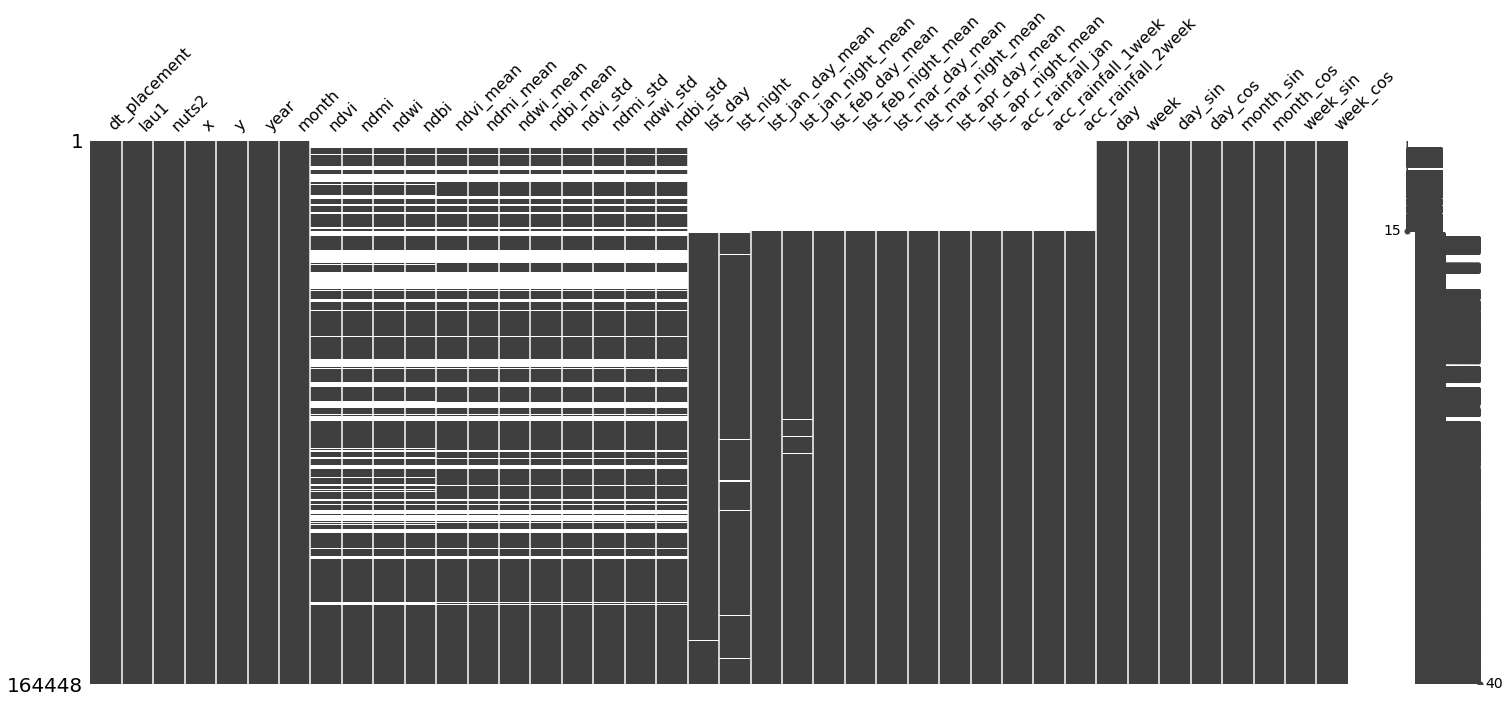

In [80]:
missingno.matrix(dataset)

In [81]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2010-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [82]:
mosquito_data.nuts2.unique()

array(['Veneto', 'Lombardia', 'Firuli-Venezia-Giulia',
       'Friuli-Venezia-Giulia'], dtype=object)

In [83]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'Veneto'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [84]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [85]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

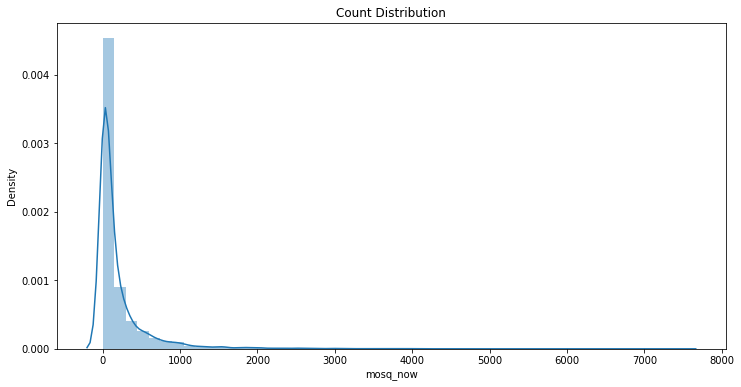

In [86]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [87]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

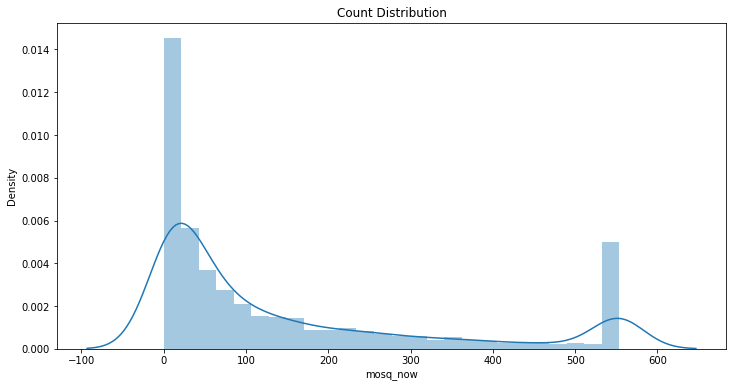

In [88]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

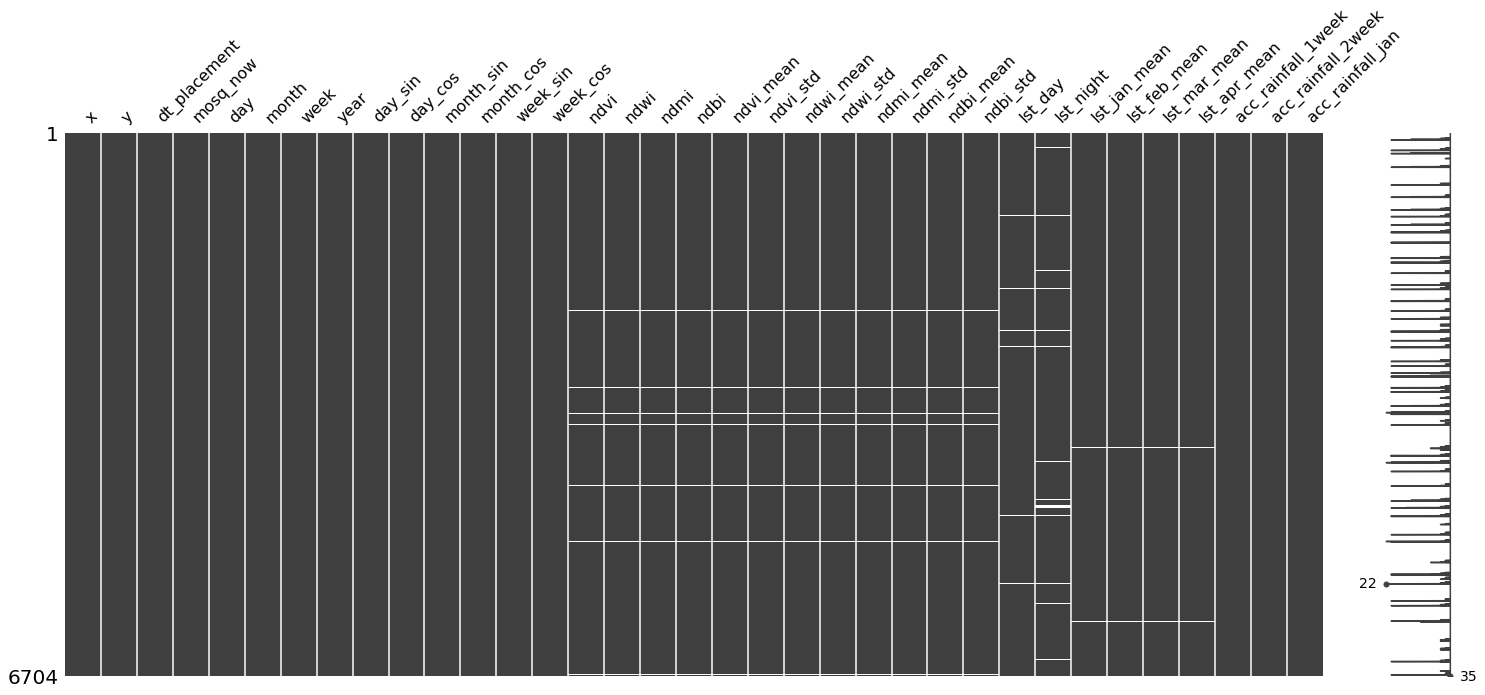

In [89]:
missingno.matrix(mosquito_data_nuts2)

In [90]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [91]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

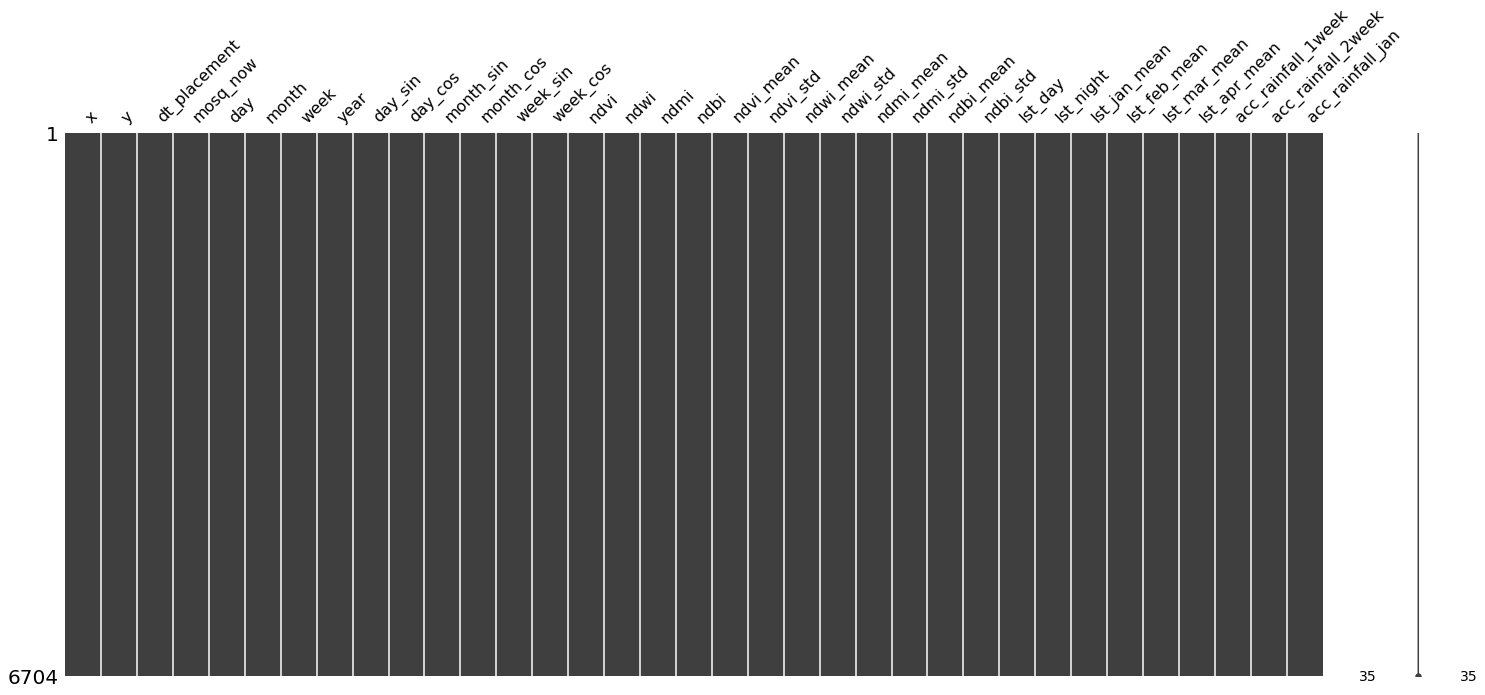

In [92]:
missingno.matrix(mosquito_data_nuts2)

In [93]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [94]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   61.  553.7]


In [95]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 7.58518 | Val Loss: 5.91475 | Train Acc: 1.960| Val Acc: 1.608
Epoch 002: | Train Loss: 5.60415 | Val Loss: 4.31321 | Train Acc: 1.554| Val Acc: 1.229
Epoch 003: | Train Loss: 5.84395 | Val Loss: 4.14604 | Train Acc: 1.600| Val Acc: 1.179
Epoch 004: | Train Loss: 5.80322 | Val Loss: 4.68372 | Train Acc: 1.579| Val Acc: 1.331
Epoch 005: | Train Loss: 5.21132 | Val Loss: 4.41162 | Train Acc: 1.482| Val Acc: 1.260
Epoch 006: | Train Loss: 5.15021 | Val Loss: 4.07852 | Train Acc: 1.458| Val Acc: 1.167
Epoch 007: | Train Loss: 5.07547 | Val Loss: 4.19985 | Train Acc: 1.433| Val Acc: 1.200
Epoch 008: | Train Loss: 4.93171 | Val Loss: 4.42588 | Train Acc: 1.412| Val Acc: 1.256
Epoch 009: | Train Loss: 4.73235 | Val Loss: 4.07968 | Train Acc: 1.366| Val Acc: 1.127
Epoch 010: | Train Loss: 4.79453 | Val Loss: 4.21195 | Train Acc: 1.371| Val Acc: 1.201
Epoch 011: | Train Loss: 4.64154 | Val Loss: 4.16618 | Train Acc: 1.351| Val Acc: 1.203
Epoch 012: | Train Loss: 4.49670

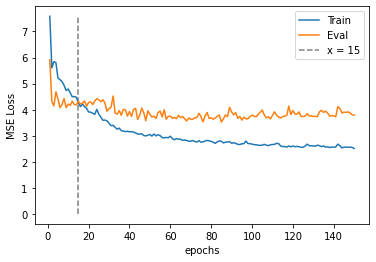

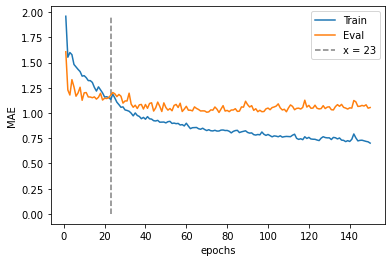

In [96]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [97]:
metrics(train, test, threshold=30)

MAE on train set:  88.23451281845587
min prediction: 1
max prediction: 686

MAE on test set:  92.71584740766795
Error ⩽ 30: 35.63 %
min prediction: 1
max prediction: 691


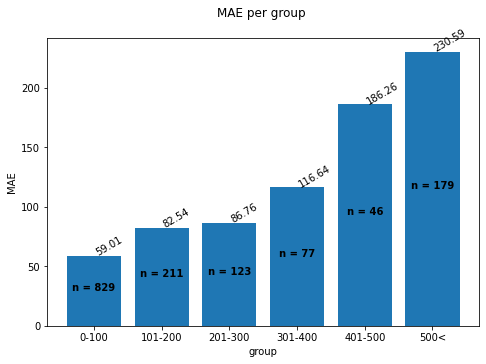

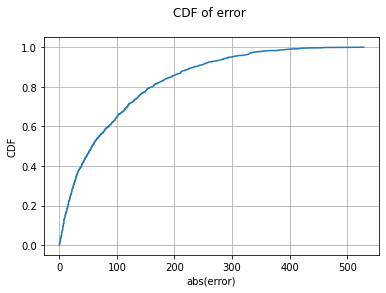

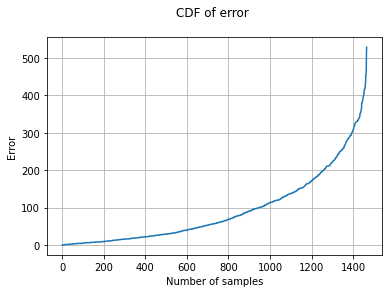

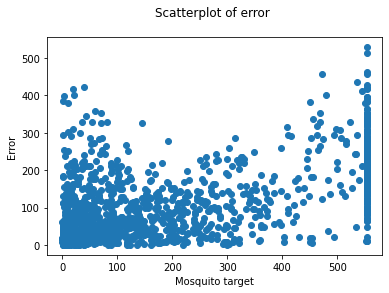

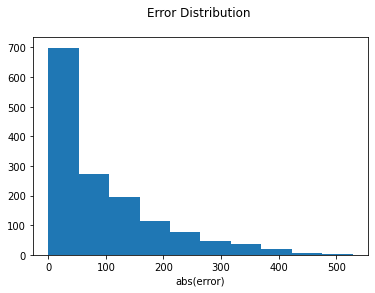

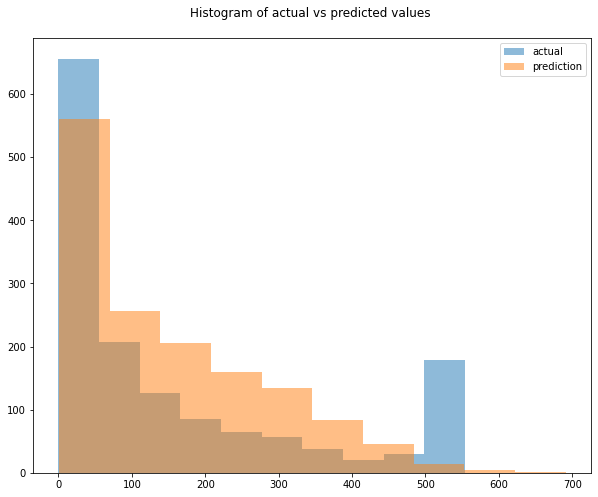

In [98]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 2.87614 | Val Loss: 0.05172 | Train Acc: 0.856| Val Acc: 0.394
Epoch 002: | Train Loss: 2.76405 | Val Loss: 0.03579 | Train Acc: 0.839| Val Acc: 0.394
Epoch 003: | Train Loss: 2.74254 | Val Loss: 0.15696 | Train Acc: 0.829| Val Acc: 0.394
Epoch 004: | Train Loss: 2.70544 | Val Loss: 0.40226 | Train Acc: 0.831| Val Acc: 0.394
Epoch 005: | Train Loss: 2.68039 | Val Loss: 0.80065 | Train Acc: 0.820| Val Acc: 1.394
Epoch 006: | Train Loss: 2.68758 | Val Loss: 0.50204 | Train Acc: 0.819| Val Acc: 0.394
Epoch 007: | Train Loss: 2.69263 | Val Loss: 0.65163 | Train Acc: 0.820| Val Acc: 0.394
Epoch 008: | Train Loss: 2.69500 | Val Loss: 0.74437 | Train Acc: 0.839| Val Acc: 0.394
Epoch 009: | Train Loss: 2.68727 | Val Loss: 0.86291 | Train Acc: 0.832| Val Acc: 1.394
Epoch 010: | Train Loss: 2.65365 | Val Loss: 1.16218 | Train Acc: 0.803| Val Acc: 1.394
Epoch 011: | Train Loss: 2.63180 | Val Loss: 0.86581 | Train Acc: 0.810| Val Acc: 1.394
Epoch 012: | Train Loss: 2.58095

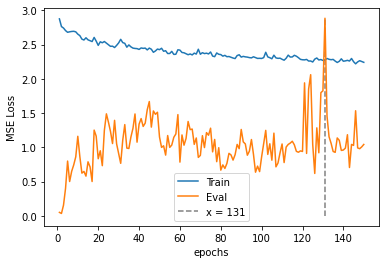

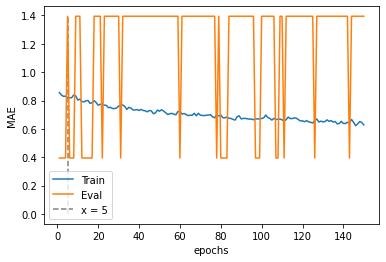

In [99]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [100]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [101]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [102]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [103]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [104]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [105]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

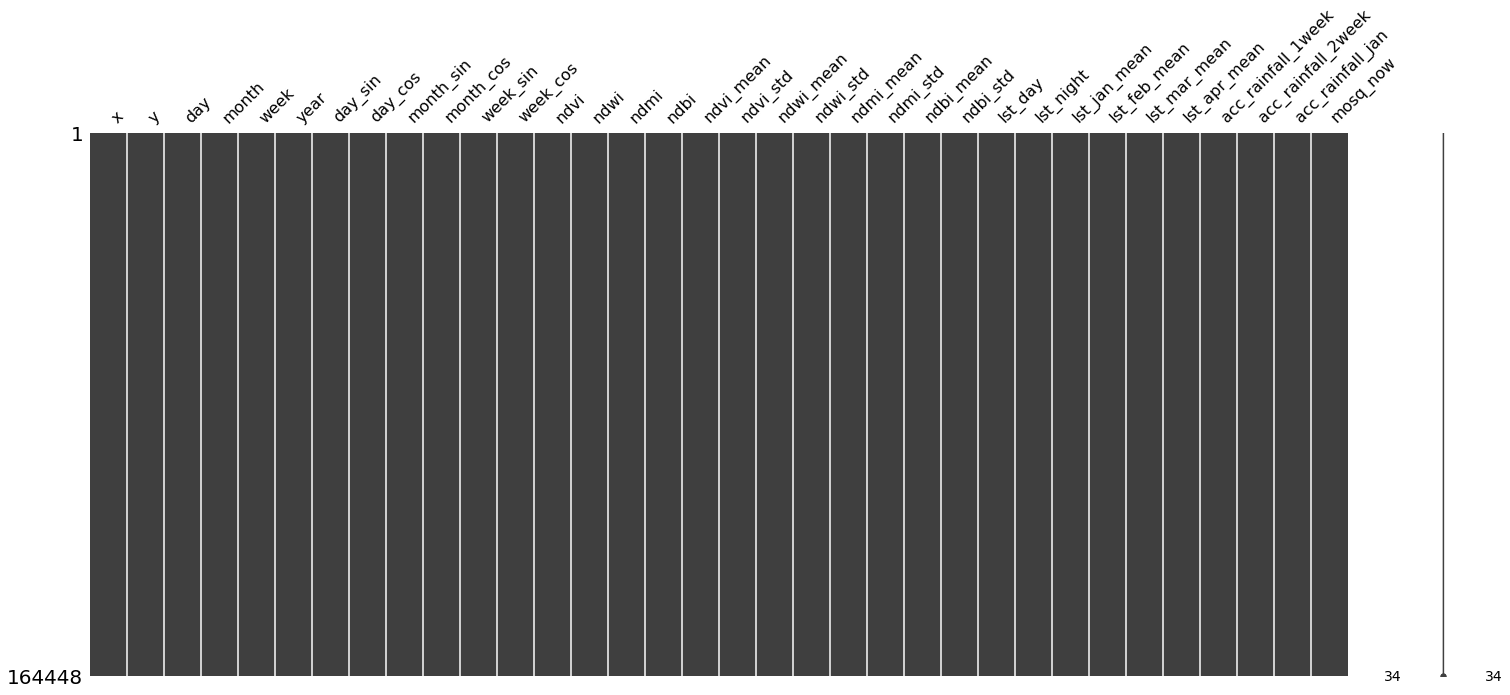

In [106]:
missingno.matrix(dataset_mamoth)

In [107]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [108]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [109]:
predictions = give_predictions(model, dataset_mamoth)

In [110]:
mosqutio_predictions['mosq_pred'] = predictions

In [111]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2008-01-01,1
1,12.049403,45.070483,2008-01-01,1
2,10.776730,45.556800,2008-01-01,7
3,11.965390,45.175310,2008-01-01,1
4,12.059120,46.313990,2008-01-01,8
...,...,...,...,...
164443,11.127335,45.353970,2019-12-16,1
164444,11.358050,45.347770,2019-12-16,1
164445,12.178780,46.388350,2019-12-16,1
164446,11.494300,45.437980,2019-12-16,1


In [113]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2008-2019.csv', index = False)